# Matplotlib: Polygon Tutorial

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 2-D Polygon
from matplotlib.patches import Polygon

# 3-D polygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import Axes3D 

# Matplotlib settings
plt.rcParams['text.usetex'] = False
plt.rcParams['font.serif'] = [ "Liberation Serif", "Times New Roman"]
plt.rcParams['font.family'] = "serif"
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

## 2-D Polygon: matplotlib.patches.Polygon

Creating simple 2D closed polygon

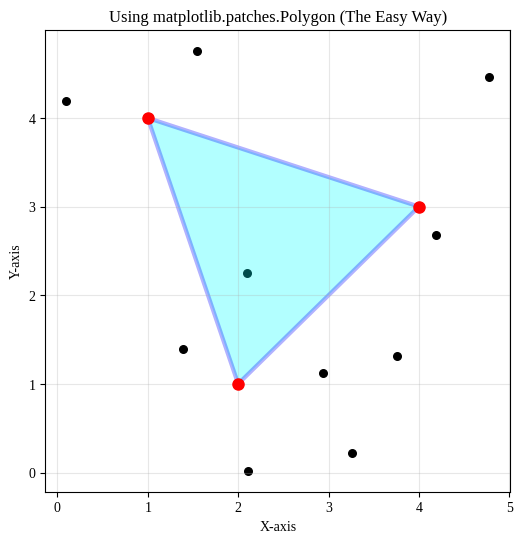

In [12]:
# Create some random data points
rng = np.random.default_rng(43)
points = rng.random((10, 2)) * 5 # 30 points in 2D

# Create some vertices for a polygon (e.g., a triangle)
vertices = np.array([[2, 1], [4, 3], [1, 4]]) # X, Y coordinates

# Create the figure and axes
fig, ax = plt.subplots(figsize=(6, 6))

# Setting axes
ax.set_title(r'Using matplotlib.patches.Polygon (The Easy Way)')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.grid(True, alpha=0.3)

# Plot random data points
ax.scatter(points[:, 0], points[:, 1], color='black', s=30, label='Data Points')

# Create the Polygon patch
# 'closed=True' is the default and ensures the shape is closed.
my_polygon = Polygon(vertices,
                    closed=True,        # Connect last to first (default)
                    edgecolor='blue',   # Color of the outline
                    linewidth=3,        # Width of the outline
                    facecolor='cyan',   # Fill color
                    alpha=0.3)          # Transparency (0=transparent, 1=opaque)

# Add the polygon to the axes
ax.add_patch(my_polygon)

# Plot the vertices for clarity
ax.plot(vertices[:, 0], vertices[:, 1], 'ro', ms=8)

ax.autoscale_view()
plt.show()

Practical Use: Filling Area Under Curve

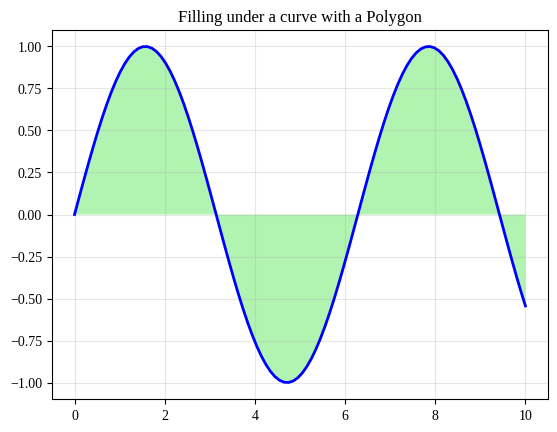

In [14]:
# Create a curve
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Define the vertices for the polygon: the curve points + the bottom corners
# We need to go along the curve and then back along the bottom.
vertices = np.vstack([np.column_stack([x, y]),  # Top: all (x, y) points
                     np.array([x[-1], 0]),     # Bottom right point
                     np.array([x[0], 0])       # Bottom left point
                    ]) # vstack combines them into one list of vertices

# Create the polygon
poly = Polygon(vertices, facecolor='lightgreen', edgecolor='none', alpha=0.7)

fig, ax = plt.subplots()
ax.grid(True, alpha=0.3)
ax.plot(x, y, 'b-', linewidth=2) # Plot the line
ax.add_patch(poly)               # Add the filled area underneath
plt.title('Filling under a curve with a Polygon')
plt.show()

## 3-D Polygon: mpl_toolkits.mplot3d.art3d.Poly3DCollection

> **Note:**
>
> There is no simple definition of the enclosed surface of a 3D polygon unless the polygon is planar.
>
> For polygons other than 2-D, you'll find orientations in which the edges of the polygon intersect in the projection. This will lead to an incorrect visualization of the 3D area.
>
> If you need filled areas, it is recommended to create them via plot_trisurf, which creates a triangulation and thus generates consistent surfaces.

Creating simple 3D closed polygon

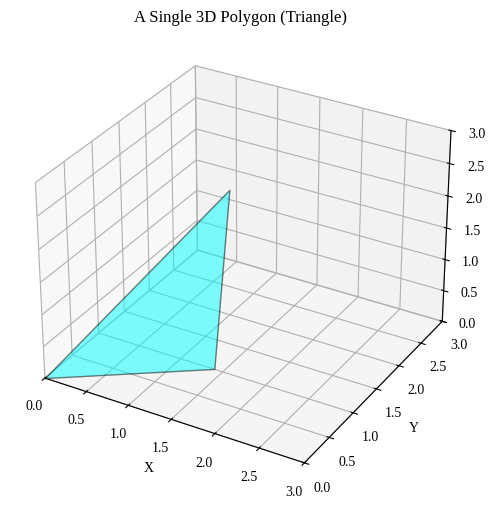

In [17]:
# Create a 3D figure and axes
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d') # Notice the '3d' projection

# Define vertices for a 3D polygon (a triangle in 3D space)
# Format: [ [x1, y1, z1], [x2, y2, z2], [x3, y3, z3] ]
vertices = np.array([
    [0, 0, 0],
    [2, 0, 1],
    [1, 2, 2]
])

# Create the Poly3DCollection. The argument must be a list of polygons.
# So we wrap our single polygon in a list: [vertices]
poly3d = Poly3DCollection([vertices], alpha=0.5, edgecolor='k', linewidth=1)

# Set the face color (can also be set in the constructor above)
poly3d.set_facecolor('cyan')

# Add the collection to the 3D axes
ax.add_collection3d(poly3d)

# Set axis limits and labels (CRUCIAL for 3D to see the object)
ax.set_xlim([0, 3])
ax.set_ylim([0, 3])
ax.set_zlim([0, 3])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('A Single 3D Polygon (Triangle)')
plt.show()

Drawing a complex 3-D object (cube)

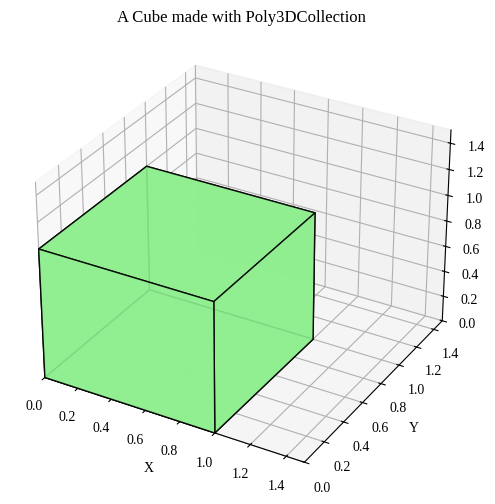

In [18]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 1. Define the 8 vertices of a cube
vertices = np.array([
    [0, 0, 0],  # Vertex 0
    [1, 0, 0],  # Vertex 1
    [1, 1, 0],  # Vertex 2
    [0, 1, 0],  # Vertex 3
    [0, 0, 1],  # Vertex 4
    [1, 0, 1],  # Vertex 5
    [1, 1, 1],  # Vertex 6
    [0, 1, 1]   # Vertex 7
])

# 2. Define which vertices form each face of the cube.
# This is a list of lists. Each sub-list contains the indices of the vertices for one face.
faces = [
    [vertices[0], vertices[1], vertices[5], vertices[4]],  # Bottom face
    [vertices[1], vertices[2], vertices[6], vertices[5]],  # Right face
    [vertices[2], vertices[3], vertices[7], vertices[6]],  # Back face
    [vertices[3], vertices[0], vertices[4], vertices[7]],  # Left face
    [vertices[4], vertices[5], vertices[6], vertices[7]],  # Top face
    [vertices[0], vertices[3], vertices[2], vertices[1]]   # Front face
]

# 3. Create the Poly3DCollection from the list of faces
cube = Poly3DCollection(faces, alpha=0.9, linewidth=1, edgecolor='k')

# 4. Set a face color. You can set different colors for each face if you want.
cube.set_facecolor('lightgreen')

# 5. Add it to the plot
ax.add_collection3d(cube)

# Set limits and labels
ax.set_xlim([0, 1.5])
ax.set_ylim([0, 1.5])
ax.set_zlim([0, 1.5])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('A Cube made with Poly3DCollection')
plt.show()

Drawing 3-D sine graph

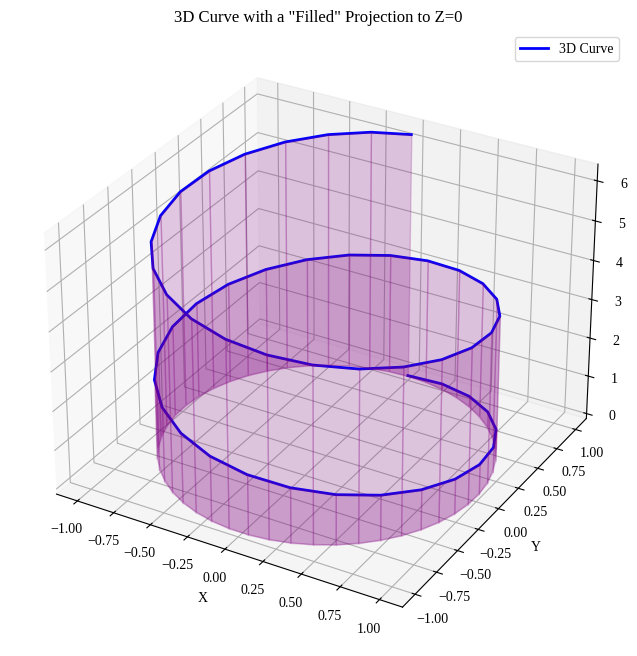

In [20]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a curve in 3D (a spiral)
t = np.linspace(0, 4 * np.pi, 50) # parameter
x = np.sin(t)
y = np.cos(t)
z = t / 2  # slowly ascending

# Plot the curve itself
ax.plot(x, y, z, 'b-', linewidth=2, label='3D Curve')

# Let's "fill" the area under the curve down to the z=0 plane.
# Strategy: Create a polygon for each segment that connects a point on the curve
# down to the corresponding point on the z=0 plane.

for i in range(len(t) - 1):
    # Define the vertices for one "ribbon" segment
    vertices = [
        [x[i], y[i], z[i]],     # Point A on the curve
        [x[i+1], y[i+1], z[i+1]], # Point B on the curve
        [x[i+1], y[i+1], 0],      # Point B projected down to Z=0
        [x[i], y[i], 0]           # Point A projected down to Z=0
    ]
    # Create a polygon for this segment and add it
    poly = Poly3DCollection([vertices], alpha=0.2, edgecolor=None, color='purple')
    ax.add_collection3d(poly)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.title('3D Curve with a "Filled" Projection to Z=0')
plt.show()

Creating a 3-D Pyramid

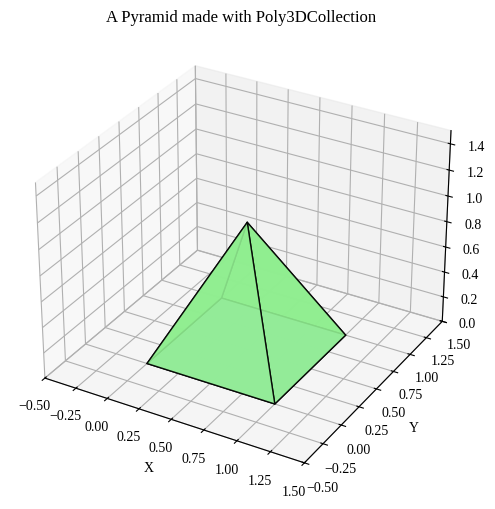

In [21]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 1. Define the 5 vertices of a square pyramid
vertices = np.array([
    [0, 0, 0],  # Base Vertex 0
    [1, 0, 0],  # Base Vertex 1
    [1, 1, 0],  # Base Vertex 2
    [0, 1, 0],  # Base Vertex 3
    [0.5, 0.5, 1]  # Apex
])

# 2. Manually define the 5 faces (1 base, 4 sides)
faces = [
    [vertices[0], vertices[1], vertices[2], vertices[3]], # Square Base
    [vertices[0], vertices[1], vertices[4]], # Side Face 1 (triangle)
    [vertices[1], vertices[2], vertices[4]], # Side Face 2
    [vertices[2], vertices[3], vertices[4]], # Side Face 3
    [vertices[3], vertices[0], vertices[4]]  # Side Face 4
]

# 3. Create the collection. We can even color faces individually.
pyramid = Poly3DCollection(faces, alpha=0.9, linewidth=1, edgecolor='k')
# Let's make the base a different color. The first face in the list is the base.
colors = ['lightblue', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen']
pyramid.set_facecolor(colors)

# 4. Add it to the plot
ax.add_collection3d(pyramid)

# Set limits and labels
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.5, 1.5])
ax.set_zlim([0, 1.5])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('A Pyramid made with Poly3DCollection')
plt.show()